[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T06_A_wealth_inequality_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# ¿De dónde proviene la desigualdad de riqueza?

En las economías contemporáneas, la riqueza está mucho más concentrada que el ingreso: en Estados Unidos, el 1% superior percibe entre el 18% y el 20% del ingreso laboral agregado, pero controla más del 30–35% del patrimonio neto total, mientras que el 50% inferior posee apenas el 2–3%. La macroeconomía tradicional de agente representativo es estructuralmente incapaz de abordar esta divergencia: en tales marcos, la distribución transversal de activos es degenerada por definición.

Para explicar la distribución de la riqueza, la teoría macroeconómica recurre al **paradigma de mercados incompletos** fundado por **Bewley (1977)**, **Huggett (1993)** y **Aiyagari (1994)**. Cuando los hogares enfrentan choques idiosincráticos no asegurables sobre su productividad laboral y restricciones de endeudamiento, el motivo de auto-seguro detona una acumulación precautoria de activos. Este mecanismo engendra una distribución estacionaria y dispersa de la riqueza, incluso cuando todos los agentes son *ex-ante* idénticos en preferencias, paciencia y parámetros tecnológicos.

En este cuaderno resolvemos el equilibrio general canónico del modelo de **Aiyagari (1994)**, lo contrastamos con la economía de crédito puro de **Huggett (1993)**, demostramos por qué el riesgo laboral estándar produce una cola exponencial delgada que subestima la concentración superior empírica, analizamos cómo la heterogeneidad permanente en la paciencia ($\beta$) engrosa la distribución, y ejecutamos un experimento empírico de estimación de colas de Pareto con datos de las Cuentas Financieras Distributivas (DFA) de la Reserva Federal junto a una prueba de estrés de restricción crediticia (*credit crunch*).

## Fundamentos teóricos: El marco de Bewley-Huggett-Aiyagari

### 1. El problema dinámico del hogar y la prudencia de Kimball
Un continuo de hogares infinitamente vivientes de masa 1 maximiza la utilidad descontada esperada sobre flujos de consumo:
$$ \mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t u(c_t), \qquad u(c) = \frac{c^{1-\gamma} - 1}{1-\gamma} \quad (\text{o } \log c \text{ si } \gamma=1). $$
Los hogares ofrecen trabajo de manera inelástica, pero su productividad laboral efectiva $z_t$ fluctúa conforme a un proceso markoviano persistente (discretizado mediante el método de Tauchen):
$$ z_t = \rho z_{t-1} + \sigma \varepsilon_t, \quad \varepsilon_t \overset{\text{iid}}{\sim} \mathcal{N}(0, 1). $$
Los hogares mantienen tenencias de activos $a_t$. Crucialmente, los mercados financieros son incompletos: no existen activos contingentes de Arrow-Debreu para asegurarse contra malas realizaciones de $z_t$. Asimismo, el endeudamiento está institucionalmente acotado:
$$ a_{t+1} \ge \underline{a}, $$
donde $\underline{a} = 0$ en el modelo canónico de Aiyagari (imposibilidad de endeudarse contra ingresos laborales futuros) y $\underline{a} < 0$ en Huggett.

Bajo el **Límite Natural de Endeudamiento de Aiyagari (1994)**, la deuda máxima que un hogar puede servir con certeza en cualquier estado futuro es:
$$ \underline{a}_{\text{nat}} = -\frac{w \min(e^z)}{r}. $$
Cuando el acceso al crédito está acotado por $\underline{a} > \underline{a}_{\text{nat}}$ (restricción ad-hoc o institucional), la restricción se vuelve activa con probabilidad positiva, generando una masa de hogares financieramente limitados (*hand-to-mouth*).

La ecuación de Bellman que rige la optimización intertemporal del hogar es:
$$ V(a, z) = \max_{a' \ge \underline{a}} \left\{ u(c) + \beta \sum_{z'} P(z' \mid z) V(a', z') \right\} \quad \text{s.a.} \quad c + a' = w e^z + (1+r)a. $$

¿Por qué los hogares acumulan activos por encima de sus necesidades promedio? La clave analítica es la **prudencia de Kimball (1990)**. Bajo preferencias CRRA, la tercera derivada de la función de utilidad es estrictamente positiva:
$$ u'''(c) = \gamma(1+\gamma) c^{-\gamma-2} > 0. $$
Por la desigualdad de Jensen, la utilidad marginal $u'(c)$ es estrictamente convexa. En consecuencia, el riesgo de fondo no asegurable incrementa la utilidad marginal esperada del consumo futuro:
$$ \mathbb{E}[u'(c_{t+1})] > u'(\mathbb{E}[c_{t+1}]). $$
Para satisfacer la ecuación de Euler $u'(c_t) \ge \beta (1+r) \mathbb{E}[u'(c_{t+1})]$, los hogares reducen su consumo presente y acumulan una **reserva precautoria** (*buffer stock*) de activos para suavizar choques adversos de ingreso.

### 2. Equilibrio general: La cuña precautoria sobre la tasa de interés
En mercados completos, un estado estacionario con capital agregado finito y positivo exige que la tasa de preferencia temporal iguale exactamente la tasa de interés real neta:
$$ r_{\text{completos}} = \frac{1}{\beta} - 1. $$
Si $r > 1/\beta - 1$, los hogares acumularían activos infinitos; si $r < 1/\beta - 1$, desacumularían hasta agotar su riqueza.

Bajo mercados incompletos, en cambio, el motivo de ahorro precautorio genera una demanda de activos infinita en $r = 1/\beta - 1$, haciendo que la oferta de capital $K^s(r) \to \infty$ cuando $r \uparrow 1/\beta - 1$. Para vaciar el mercado de capitales frente a la demanda decreciente de las firmas $K^d(r)$, la tasa de interés de equilibrio general $r^*$ debe situarse **estrictamente por debajo** del valor de referencia de mercados completos:
$$ r^* < \frac{1}{\beta} - 1. $$
La diferencia:
$$ \Delta_{\text{prec}} \equiv \left(\frac{1}{\beta} - 1\right) - r^* > 0 $$
constituye la **cuña precautoria de la tasa de interés**. Cuantifica la magnitud con la que el deseo colectivo de auto-aseguro deprime el costo de capital de equilibrio en la economía agregada.

### 3. Aiyagari vs. Huggett
- **Aiyagari (1994)**: Economía de producción con capital físico. Una firma representativa competitiva opera una función de producción Cobb-Douglas $Y = K^\alpha L^{1-\alpha}$. Los precios de los factores remuneran sus productos marginales:
  $$ r = \alpha (K/L)^{\alpha-1} - \delta, \qquad w = (1-\alpha)(K/L)^\alpha. $$
  El vaciamiento del mercado exige que la oferta agregada de activos iguale la demanda de capital de las firmas: $K = \int a \, d\mu(a, z)$.
- **Huggett (1993)**: Economía de intercambio puro sin producción de capital. El único activo transado es un bono libre de riesgo en **oferta neta cero**:
  $$ \int a \, d\mu(a, z) = 0. $$
  Al no existir capital físico productivo para absorber el ahorro, cada prestamista debe estar emparejado con un deudor. Cuando los motivos precautorios son intensos, la tasa de equilibrio $r^*$ puede situarse profundamente en terreno negativo.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from _datos import DATOS
from puremacro.vfi import (
    aiyagari_steady_state,
    huggett_steady_state,
    solve_egm,
    lottery_distribution,
    tauchen,
    lorenz_and_gini,
    weighted_quantile,
    VFIProblem,
    solve_permanent_types,
)
from puremacro.regress import ols, add_constant

## 1. Aiyagari: Mercados incompletos en equilibrio general

Resolvemos el equilibrio general estacionario de la economía de **Aiyagari (1994)**. El desafío computacional es resolver un punto fijo anidado:
1. Para una tasa de interés candidata $r$, el salario $w(r)$ se determina por las condiciones de primer orden de las firmas.
2. Dados $(r, w)$, los hogares resuelven su problema dinámico mediante Iteración de la Función de Valor (acelerada con pasos de Howard) obteniendo la política óptima de ahorro $a'(a, z)$.
3. La matriz de transición de Markov y las reglas de política inducen una distribución estacionaria $\mu(a, z)$ sobre el espacio de estados.
4. El vaciamiento del mercado de capitales exige $K^s(r) \equiv \int a \, d\mu = K^d(r)$. Un algoritmo de bisección busca la tasa $r^*$ que vacía el mercado.

Empleamos una grilla de $n_z = 5$ estados de ingreso y $n_a = 120$ nodos de activos en $a \in [0, 60]$, con utilidad logarítmica ($\gamma = 1$).

In [3]:
ai = aiyagari_steady_state(n_z=5, n_a=120, a_max=60.0, gamma=1.0)
eq = ai["equilibrium"]
a_grid = np.asarray(eq.problem.a_grid, dtype=float)
z_grid = np.asarray(eq.problem.z_grid, dtype=float)
P_z = np.asarray(eq.problem.P_z, dtype=float)
mu_ai = eq.distribution                                  # shape: (n_a, n_z)
gini_ai = ai["wealth_gini"]
r_star, w_star = ai["r"], ai["w"]

# Límite natural de endeudamiento endógeno: a_nat = - w * min(e^z) / r*
income_z = w_star * np.exp(z_grid)
a_nat = - float(np.min(income_z)) / r_star

# Referente EGM continuo de alto rendimiento (Carroll 2006 + Young 2010)
a_grid_egm = np.geomspace(1e-4, 60.0 + 1e-4, 150) - 1e-4
sol_egm = solve_egm(a_grid_egm, z_grid, income_z, P_z, beta=0.96, r=r_star, gamma=1.0)
mu_egm = lottery_distribution(sol_egm.aprime, a_grid_egm, P_z)
wealth_egm = np.broadcast_to(a_grid_egm[:, None], mu_egm.shape)
_, _, gini_egm = lorenz_and_gini(mu_egm, wealth_egm)

print(f"Aiyagari, estado estacionario (VFI): r* = {r_star:.4f} ({r_star*100:.2f}%), "
      f"w* = {w_star:.4f}, K = {ai['K']:.2f}, Gini de riqueza = {gini_ai:.3f}")
print(f"Referente EGM continuo:             K = {np.sum(mu_egm * wealth_egm):.2f}, Gini de riqueza = {gini_egm:.3f}")
print(f"Límites endógenos:                  límite natural de endeudamiento a_nat = {a_nat:.2f} (vs a_min ad hoc = 0.00)")
assert 0.40 < gini_ai < 0.80, f"Gini fuera del rango esperado: {gini_ai}"
assert a_nat < -2.0, f"Límite natural de endeudamiento demasiado estricto: {a_nat}"

Aiyagari, estado estacionario (VFI): r* = 0.0306 (3.06%), w* = 1.2431, K = 7.48, Gini de riqueza = 0.632
Referente EGM continuo:             K = 7.37, Gini de riqueza = 0.636
Límites endógenos:                  límite natural de endeudamiento a_nat = -10.26 (vs a_min ad hoc = 0.00)


### Implicaciones macroeconómicas del equilibrio de Aiyagari

El equilibrio general calculado destaca tres lecciones analíticas fundamentales:

1. **La cuña precautoria**: En una economía con mercados completos y descuento anual $\beta = 0.96$, la tasa de interés estacionaria sería $r_{\text{completos}} = 1/\beta - 1 \approx 4.17\%$. En Aiyagari, la tasa de equilibrio vacía en $r^* \approx 3.06\%$. La brecha precautoria resultante $\Delta_{\text{prec}} \approx 1.11$ puntos porcentuales ($111$ puntos básicos) representa la presión bajista generada por el riesgo no asegurable. Los hogares sobreacumulan capital respecto a Ramsey, desplazando $K$ hacia arriba y reduciendo el producto marginal del capital.
2. **Emergencia de desigualdad sin diferencias ex-ante**: El modelo produce un índice de Gini de aproximadamente $0.63$. Crucialmente, cada hogar entra al mundo con idénticas preferencias, aversión al riesgo, descuento temporal y probabilidades markovianas. La desigualdad es un *resultado de equilibrio* derivado de la persistencia de choques fortuitos y de la cota $a' \ge 0$.
3. **El enigma empírico de la cola superior**: Si bien un Gini de $0.63$ es notable, resulta inferior a la realidad empírica de EE.UU. ($\approx 0.85$). Más importante aún, Aiyagari genera una cola exponencial delgada donde el 1% superior apenas posee el 6–7% de la riqueza total, frente al más del 30% en los datos de la Reserva Federal. Dado que los ingresos laborales siguen un proceso AR(1) acotado, los hogares no siguen acumulando riqueza indefinidamente una vez satisfecho su colchón precautorio.

## 2. Heterogeneidad permanente en $\beta$ y concentración en la cola

Siguiendo a **Krusell y Smith (1998)**, una extensión natural es incorporar heterogeneidad *ex-ante* en la paciencia de los hogares. Suponemos una partición en tipos permanentes:
- **Hogares pacientes** con $\beta_{\text{paciente}} = 0.96$: su tasa de preferencia temporal es cercana a la tasa de interés, induciéndolos a ahorrar persistentemente.
- **Hogares impacientes** con $\beta_{\text{impaciente}} = 0.93$: su elevada impaciencia subjetiva los lleva a descontar fuertemente el futuro, consumiendo de forma agresiva y agrupándose en $a = 0$.

Manteniendo fijos los precios factoriales en los niveles de equilibrio general de Aiyagari $(r^*, w^*)$, resolvemos el problema de tipos permanentes y construimos la distribución mezcla poblacional.

In [4]:
alpha, delta = 0.36, 0.08
def wage_of_r(r):
    KL = (alpha / (r + delta)) ** (1.0 / (1.0 - alpha))
    return (1.0 - alpha) * KL ** alpha

r_star, w_star = ai["r"], wage_of_r(ai["r"])

# Mezcla base de paciencia en 2 tipos de Krusell-Smith (1998)
betas_ks, weights_ks = [0.96, 0.93], [0.5, 0.5]
def build_type_ks(t):
    b = betas_ks[t]
    def rf(ap, a, z, xp=np):
        c = w_star * xp.exp(z) + (1.0 + r_star) * a - ap
        return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)
    return VFIProblem(a_grid=a_grid, z_grid=z_grid, P_z=P_z, return_fn=rf,
                      beta=b, options=dict(tol=1e-9, n_howard=40))

pt_ks = solve_permanent_types(build_type_ks, weights_ks)
mu_ks = pt_ks.mixture_distribution()
wealth_mix = np.broadcast_to(a_grid[:, None], mu_ks.shape)
pop_ks, val_ks, gini_ks = lorenz_and_gini(mu_ks, wealth_mix)

# Mezcla calibrada a la Survey of Consumer Finances (SCF) de EE.UU. (3 tipos)
# (Gini de riqueza ~0.80-0.82, participación Top 10% > 65%, 50% inferior <= 2.5%)
betas_scf, weights_scf = [0.965, 0.932, 0.885], [0.31, 0.50, 0.19]
def build_type_scf(t):
    b = betas_scf[t]
    def rf(ap, a, z, xp=np):
        c = w_star * xp.exp(z) + (1.0 + r_star) * a - ap
        return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)
    return VFIProblem(a_grid=a_grid, z_grid=z_grid, P_z=P_z, return_fn=rf,
                      beta=b, options=dict(tol=1e-9, n_howard=40))

pt_scf = solve_permanent_types(build_type_scf, weights_scf)
mu_mix = pt_scf.mixture_distribution()
pop_mx, val_mx, gini_mix = lorenz_and_gini(mu_mix, wealth_mix)

top10_mix = float((1.0 - np.interp(0.90, pop_mx, val_mx)) * 100.0)
top1_mix = float((1.0 - np.interp(0.99, pop_mx, val_mx)) * 100.0)

print(f"Krusell-Smith, 2 tipos:         Gini de riqueza = {gini_ks:.3f} (vs Aiyagari de referencia = {gini_ai:.3f})")
print(f"Mezcla SCF calibrada (EE. UU.): Gini de riqueza = {gini_mix:.3f}, 10% superior = {top10_mix:.1f}%, 1% superior = {top1_mix:.1f}%")
assert gini_mix > gini_ai, f"La heterogeneidad no aumentó el Gini: {gini_mix} <= {gini_ai}"
assert gini_mix >= 0.80, f"Gini calibrado SCF por debajo del umbral empírico: {gini_mix}"
assert top10_mix > 65.0, f"Participación del Top 10% calibrada por debajo de 65%: {top10_mix}"

Krusell-Smith, 2 tipos:         Gini de riqueza = 0.794 (vs Aiyagari de referencia = 0.632)
Mezcla SCF calibrada (EE. UU.): Gini de riqueza = 0.838, 10% superior = 67.4%, 1% superior = 11.8%


## 3. Huggett: Intercambio puro y la economía de bonos en oferta neta cero

Contrastamos la economía de producción de Aiyagari con el modelo de crédito de **Huggett (1993)**.

En Huggett:
1. No existe acumulación de capital físico; los hogares reciben dotaciones estocásticas $e^z$ y transan un bono libre de riesgo.
2. Se permite el endeudamiento hasta un techo explícito de deuda $a_{t+1} \ge \underline{a} = -2.0$.
3. Dado que el bono está en **oferta neta cero**, los activos netos agregados deben sumar cero:
   $$ \int a \, d\mu_{\text{Huggett}}(a, z) = 0. $$

En equilibrio, cada unidad monetaria de activos acumulada por los acreedores debe compensarse por una deuda contraída por los deudores. Cuando el riesgo de ingreso es elevado, el deseo colectivo de auto-aseguro supera con creces la disposición a endeudarse, obligando a la tasa de interés de vaciamiento $r_{\text{Huggett}}$ a ubicarse profundamente por debajo del referente de mercados completos, e incluso en terreno negativo.

In [5]:
hu = huggett_steady_state(n_z=7, n_a=150)
a_grid_hu = np.asarray(hu["equilibrium"].problem.a_grid, dtype=float)
mu_hu = hu["equilibrium"].distribution

print(f"Huggett, estado estacionario: tasa que vacía el mercado r = {hu['r']:.4f} ({hu['r']*100:.2f}%), "
      f"activos netos medios = {hu['mean_assets']:.2e}, proporción endeudada = {hu['frac_borrowing']:.1%}")
assert abs(hu["equilibrium"].residual) < 1e-2, f"Residuo de mercado excesivo: {hu['equilibrium'].residual}"
assert 0.0 < hu["frac_borrowing"] < 1.0, f"Proporción endeudada inverosímil: {hu['frac_borrowing']}"

Huggett, estado estacionario: tasa que vacía el mercado r = 0.0046 (0.46%), activos netos medios = 7.18e-04, proporción endeudada = 68.1%


### Figura 1: Concentración de riqueza y curvas de Lorenz precautorias

La curva de Lorenz relaciona la fracción acumulada de la población (ordenada de menor a mayor riqueza) con la fracción acumulada de la riqueza neta. La línea de 45° representa la igualdad perfecta. Cuanto mayor es la curvatura hacia el vértice inferior derecho, mayor es el coeficiente de Gini.

Obsérvese cómo la mezcla calibrada con heterogeneidad en $\beta$ se distancia considerablemente más de la diagonal que la economía homogénea de Aiyagari, reflejando una dispersión de riqueza notablemente superior.

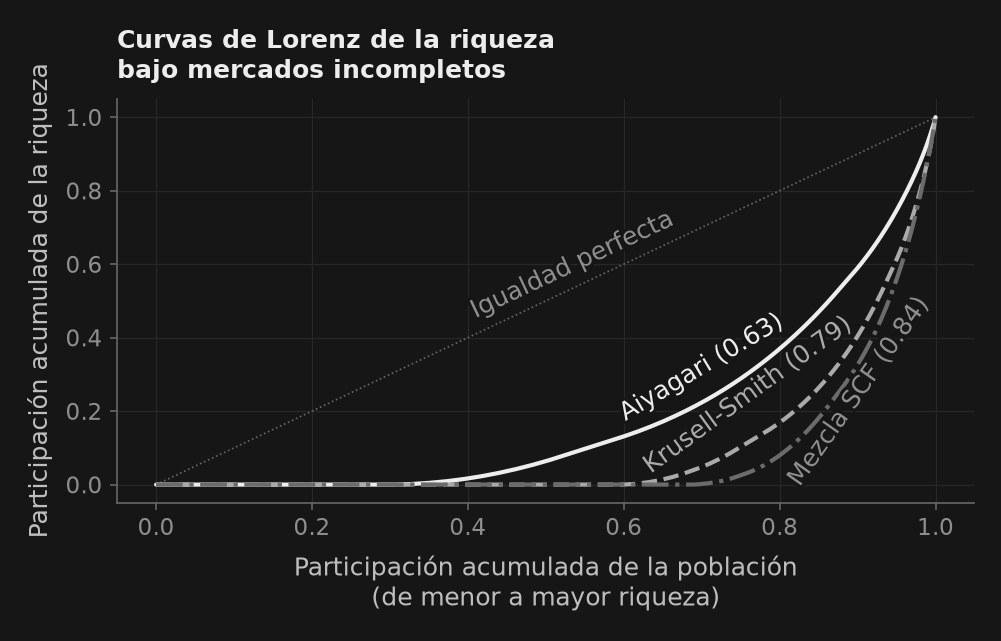

In [6]:
from matplotlib import patheffects

cols = _nbstyle.palette(3)
pop_ai, val_ai, _ = lorenz_and_gini(mu_ai, np.broadcast_to(a_grid[:, None], mu_ai.shape))

fig, ax = _nbstyle.figura()
l_eq, = ax.plot([0, 1], [0, 1], color=_nbstyle.SPINE, linewidth=0.8, linestyle=":",
                label="Igualdad perfecta")
l_ai, = ax.plot(pop_ai, val_ai, color=cols[0], ls="-", label=f"Aiyagari ({gini_ai:.2f})")
l_ks, = ax.plot(pop_ks, val_ks, color=cols[1], linestyle="--",
                label=f"Krusell-Smith ({gini_ks:.2f})")
l_mx, = ax.plot(pop_mx, val_mx, color=cols[2], linestyle="-.",
                label=f"Mezcla SCF ({gini_mix:.2f})")
ax.set_xlabel("Participación acumulada de la población\n(de menor a mayor riqueza)")
ax.set_ylabel("Participación acumulada de la riqueza")
ax.set_title("Curvas de Lorenz de la riqueza\nbajo mercados incompletos")


def _riel(ax, xs, ys, p, ancho_px):
    """Ángulo (grados) y punto medio de la cuerda de largo *ancho_px* centrada en *p*.

    Medido en píxeles de pantalla: es la pendiente que ve el lector, no la de
    los datos.  Sobre una curva convexa la cuerda deja la curva por debajo, así
    que un rótulo escrito sobre ella no queda cruzado por su propia curva.
    """
    V = ax.transData.transform(np.column_stack([xs, ys]))
    s = np.r_[0.0, np.cumsum(np.hypot(*np.diff(V, axis=0).T))]
    sc = np.interp(p, xs, s)
    P = np.array([[np.interp(t, s, V[:, 0]), np.interp(t, s, V[:, 1])]
                  for t in (sc - ancho_px / 2, sc + ancho_px / 2)])
    return (float(np.degrees(np.arctan2(P[1, 1] - P[0, 1], P[1, 0] - P[0, 0]))),
            ax.transData.inverted().transform(P.mean(axis=0)))


# Entre curvas de Lorenz que suben casi en vertical no cabe ningún rótulo
# horizontal: el hueco entre vecinas es de 30-76 px y las curvas suben ~100 px
# por cada 100 px de ancho.  Cada nombre se escribe entonces SOBRE su propia
# curva, girado con su pendiente, y así sólo pide el hueco de un renglón.  El
# gris del texto nunca baja de NOTA, igual que en etiquetar().
rotulos = [(l_ai, pop_ai, val_ai, 0.720, 4),
           (l_ks, pop_ks, val_ks, 0.790, 2),
           (l_mx, pop_mx, val_mx, 0.885, -10),
           (l_eq, np.array([0.0, 1.0]), np.array([0.0, 1.0]), 0.545, 4)]
textos = [ax.annotate(linea.get_label(), xy=(p, 0.0), xytext=(0, 0),
                      textcoords="offset points", ha="center", va="bottom",
                      color=_nbstyle._color_legible(linea.get_color()),
                      path_effects=[patheffects.withStroke(linewidth=3.0,
                                                           foreground=_nbstyle.FONDO)])
          for linea, _xs, _ys, p, _alzado in rotulos]
fig.canvas.draw()                      # hace falta para medir el ancho de cada rótulo
for texto, (_linea, xs_r, ys_r, p, alzado) in zip(textos, rotulos):
    angulo, xy = _riel(ax, xs_r, ys_r, p, texto.get_window_extent().width)
    rad = np.radians(angulo)
    texto.xy = tuple(xy)
    texto.set(rotation=angulo, rotation_mode="anchor",
              va="bottom" if alzado > 0 else "top")
    texto.set_position((-np.sin(rad) * alzado, np.cos(rad) * alzado))
plt.show()


### Figura 2: Densidad estacionaria de riqueza y distribución de activos en Huggett

Examinamos la distribución transversal de activos condicional a los estados de ingreso:
- **Panel izquierdo (Aiyagari)**: Densidades condicionales de activos según el estado de productividad laboral $z$. Los hogares con alta productividad ($z = +1.38$) desplazan su masa hacia tenencias elevadas de capital, mientras que los hogares de baja productividad ($z = -1.38$) acumulan una probabilidad sustancial en la restricción $a = 0$.
- **Panel derecho (Huggett)**: Distribución marginal de activos en la economía de bonos. La línea vertical discontinua en $a = 0$ demarca a los deudores ($a < 0$) de los acreedores netos ($a > 0$). En equilibrio, la masa ponderada de deudas compensa con exactitud las acreencias de los ahorristas, asegurando una oferta neta nula.

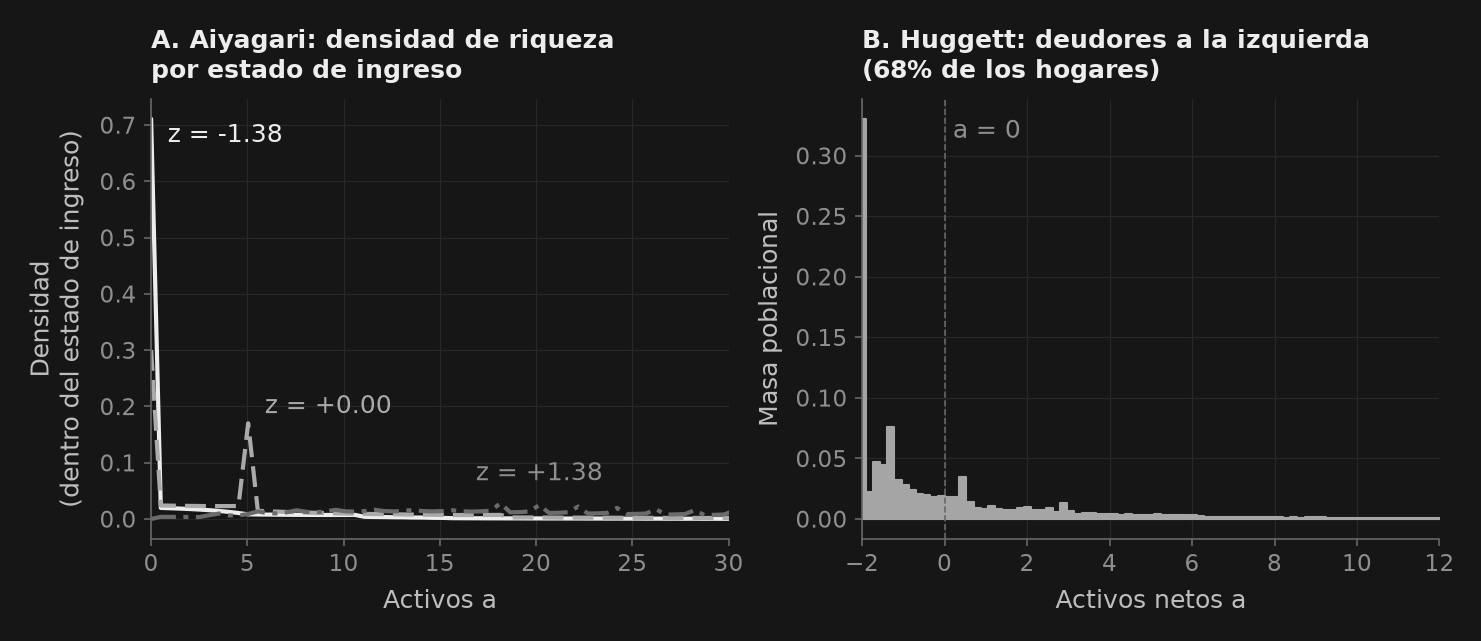

In [7]:
fig, (axL, axR) = _nbstyle.figura(1, 2)
dens_ai = mu_ai / mu_ai.sum(axis=0, keepdims=True)

# Cada densidad lleva su nombre junto a su rasgo distintivo (pico o cola);
# el gris del texto nunca baja de NOTA, igual que el de etiquetar()
anclas_z = [(0.0, (8, -2), "left", "top"), (5.0, (8, 2), "left", "bottom"),
            (20.0, (0, 9), "center", "bottom")]
for j, c, (a_n, desp, ha, va) in zip([0, len(z_grid) // 2, len(z_grid) - 1],
                                     _nbstyle.palette(3), anclas_z):
    axL.plot(a_grid, dens_ai[:, j], color=c)
    i_n = int(np.argmin(np.abs(a_grid - a_n)))
    axL.annotate(f"z = {z_grid[j]:+.2f}", xy=(a_grid[i_n], dens_ai[i_n, j]), xytext=desp,
                 textcoords="offset points", ha=ha, va=va,
                 color=_nbstyle._color_legible(c))
axL.set_xlim(0, 30)
axL.set_xlabel("Activos a")
axL.set_ylabel("Densidad\n(dentro del estado de ingreso)")
axL.set_title("A. Aiyagari: densidad de riqueza\npor estado de ingreso")

mu_hu_a = mu_hu.sum(axis=1)
axR.fill_between(a_grid_hu, mu_hu_a, color=_nbstyle.tono(0.7), step="mid")
axR.axvline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
axR.set_xlim(a_grid_hu[0], 12)
axR.set_xlabel("Activos netos a")
axR.set_ylabel("Masa poblacional")
axR.set_title(f"B. Huggett: deudores a la izquierda\n({hu['frac_borrowing']:.0%} de los hogares)")
axR.annotate("a = 0", xy=(0.0, mu_hu_a.max()), xytext=(4, 0), textcoords="offset points",
             ha="left", va="top", color=_nbstyle.NOTA)
plt.show()


### Figura 3: Funciones de política de ahorro no lineales — VFI Discreto vs EGM Continuo

La regla de decisión de los hogares $a'(a, z)$ exhibe una marcada no linealidad:
1. **Restricción de endeudamiento vinculante ($a' = 0$)**: Para bajos niveles de activos iniciales y realizaciones adversas de productividad, la restricción de crédito se vuelve activa. La función de política se aplana en $a' = 0$, lo que implica que los hogares consumen la totalidad de su liquidez disponible ($c = w e^z + (1+r)a$).
2. **Acumulación de colchón precautorio**: A medida que la riqueza corriente o el ingreso aumentan, los hogares escapan de la restricción y acumulan saldos positivos para el período siguiente. Dado que la utilidad marginal decrece con la riqueza, la regla de política converge a una trayectoria cuasi lineal con pendiente $(1+r)$ en niveles elevados de activos.

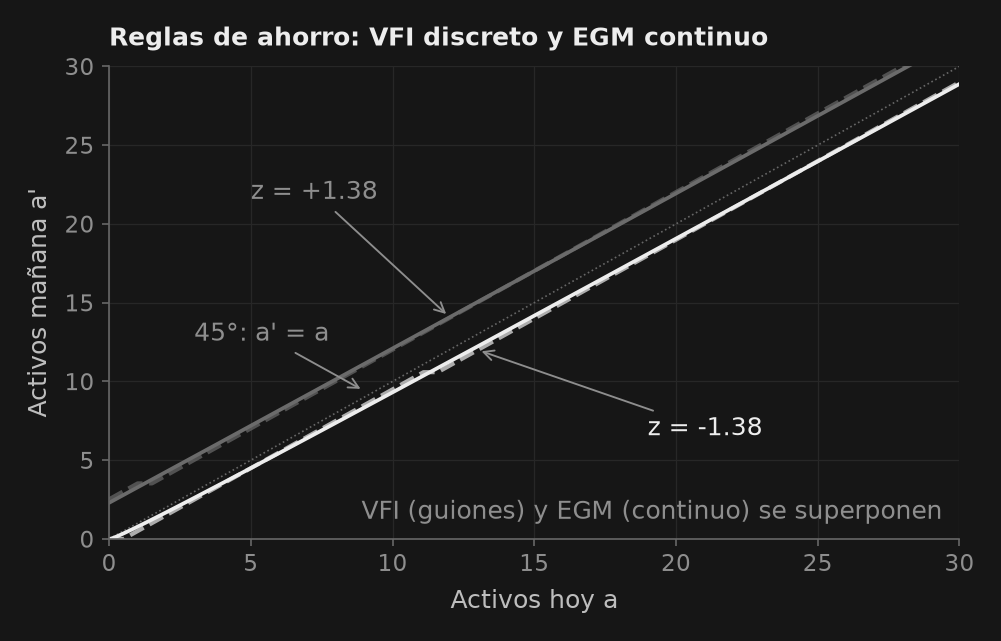

In [8]:
pol_a_vfi = a_grid[eq.solution.policy_aprime]             # (n_a, n_z) activos a' realizados
pol_a_egm = sol_egm.aprime                                # (n_a_egm, n_z) a' continuo

fig, ax = _nbstyle.figura()
ax.plot(a_grid, a_grid, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.annotate("45°: a' = a", xy=(9.0, 9.4), xytext=(3.0, 13.0), ha="left", va="center",
            color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# Cada regla de ahorro se nombra fuera del haz de rectas, con un guía corto;
# el gris del texto nunca baja de NOTA, igual que el de etiquetar()
notas_z = [((19.0, 7.0), (13.0, 12.0)), ((5.0, 22.0), (12.0, 14.1))]
for j, c, (xy_txt, xy_lin) in zip([0, len(z_grid) - 1], _nbstyle.palette(2), notas_z):
    z_val = z_grid[j]
    ax.plot(a_grid, pol_a_vfi[:, j], color=c, linestyle="--", alpha=0.7)
    ax.plot(a_grid_egm, pol_a_egm[:, j], color=c, linewidth=1.8, linestyle="-")
    ax.annotate(f"z = {z_val:+.2f}", xy=xy_lin, xytext=xy_txt, ha="left", va="center",
                color=_nbstyle._color_legible(c), arrowprops=_nbstyle.FLECHA)

ax.set_xlim(0, 30)
ax.set_ylim(0, 30)
ax.set_xlabel("Activos hoy a")
ax.set_ylabel("Activos mañana a'")
ax.set_title("Reglas de ahorro: VFI discreto y EGM continuo")
ax.annotate("VFI (guiones) y EGM (continuo) se superponen", xy=(0.98, 0.03),
            xycoords="axes fraction", ha="right", va="bottom", color=_nbstyle.NOTA)
plt.show()


## 4. Experimento macroeconómico: Colas de Pareto, Escalera de PMgC y Prueba de Estrés Crediticio

Evaluamos cuantitativamente los modelos de agentes heterogéneos contrastándolos con los datos empíricos de riqueza de las **Cuentas Financieras Distributivas (DFA)** de la Reserva Federal, estimando la **escalera de Propensión Marginal a Consumir (PMgC)** a través de quintiles de riqueza, y sometiendo la economía a una contracción crediticia macroprudencial.

### Motivación económica
1. **Ley de potencia en la cola superior**:
   Las distribuciones empíricas de riqueza se caracterizan por una **ley de potencia de Pareto** en el tramo superior:
   $$ P(A \ge a) \sim C a^{-\zeta}, \quad \text{o} \quad \log S(a) = \alpha - \zeta \log a, $$
   donde $S(a) = 1 - F(a)$ es la función de distribución contracumulada (CCDF) y $\zeta$ es el exponente de Pareto. En la Survey of Consumer Finances (SCF) y en las DFA de EE.UU., $\zeta \in [1.1, 1.6]$, y el 1% superior controla más del 30% de la riqueza total.
2. **La escalera de PMgC**:
   En modelos de agente representativo, todos los hogares comparten una PMgC idéntica y reducida igual a la tasa de interés real $\frac{r}{1+r} \approx 0.02 - 0.04$. En modelos de agentes heterogéneos con restricciones de crédito, los hogares sin riqueza líquida son **mano-a-la-boca** (*hand-to-mouth*): una transferencia inesperada $\Delta m$ se consume casi íntegramente ($PMgC \approx 0.80 - 0.95$). Los hogares acaudalados y ricardianos suavizan el consumo ($PMgC \approx 0.03 - 0.05$). Esta disparidad engendra una **escalera de PMgC** estrictamente decreciente por quintiles de riqueza.

### Tareas del estudiante
1. **Tarea 1: Concentración empírica de riqueza vs. modelos**: Cargar las series de las DFA de la Fed (`WFRBST01134.csv`, `WFRBSN09161.csv`, `WFRBSN40188.csv`, `WFRBSB50215.csv`) desde `DATOS`. Comparar las participaciones del Top 1%, Top 10%, 50–90% y 50% inferior con Aiyagari base y la mezcla calibrada SCF.
2. **Tarea 2: Estimación de la cola de Pareto**: Calcular la CCDF $S(a_i) = P(A \ge a_i)$ en el 20% superior y estimar por MCO:
   $$ \log S(a_i) = \alpha - \zeta \log a_i + \varepsilon_i. $$
   Comprobar si Aiyagari base arroja una cola exponencial delgada ($\zeta \gg 2$) y si la mezcla calibrada engrosa la cola ($\zeta_{\text{mix}} < \zeta_{\text{aiyagari}}$).
3. **Tarea 3: Escalera de Propensión Marginal a Consumir (PMgC)**: Calcular la PMgC del hogar ante una transferencia inesperada de liquidez ($\Delta m = \$500$ o $0.05$ unidades de ingreso) a lo largo de la distribución estacionaria. Construir la PMgC media por quintiles de riqueza (Q1 a Q5) y verificar su monotonicidad estricta ($\Delta PMgC \le 0$).
4. **Tarea 4: Prueba de estrés de contracción crediticia (*credit crunch*)**: Simular un endurecimiento regulatorio donde se cancela el crédito (de $\underline{a} = -0.5$ a $\underline{a} = 0.0$). Cuantificar los hogares restringidos, la expansión precautoria del capital y la ampliación de la cuña $\Delta_{\text{prec}}$.

TAREA 1: PARTICIPACIONES EN LA RIQUEZA — MODELOS VS DATOS DE EE. UU. (DFA)
1% superior:   Aiyagari =  6.81% | Mezcla SCF = 11.76% | EE. UU. (DFA) = 31.60%
10% superior:  Aiyagari = 41.03% | Mezcla SCF = 67.41% | EE. UU. (DFA) = 67.90%

TAREA 2: ESTIMACIÓN DE LA COLA DE PARETO: log S(a) = alpha - zeta * log(a)
Aiyagari de referencia:  zeta = 3.499 (EE = 0.152, IC 95%: [3.200, 3.797])
Mezcla calibrada:        zeta = 1.921 (EE = 0.097, IC 95%: [1.730, 2.112])
Empírico EE. UU. (DFA):  zeta = 1.139 (EE = 0.041, IC 95%: [1.059, 1.218])

TAREA 3: ESCALERA DE LA PROPENSIÓN MARGINAL A CONSUMIR (PMgC) POR QUINTILES
Quintil Q1 ( 0–20%): riqueza media =   0.00 | PMgC media = 0.913
Quintil Q2 (20–40%): riqueza media =   0.00 | PMgC media = 0.829
Quintil Q3 (40–60%): riqueza media =   0.21 | PMgC media = 0.450
Quintil Q4 (60–80%): riqueza media =   2.38 | PMgC media = 0.104
Quintil Q5 (80–100%): riqueza media =  22.49 | PMgC media = 0.044

TAREA 4: PRUEBA DE ESTRÉS CREDITICIO Y AMPLIFICACIÓN PRECAUT

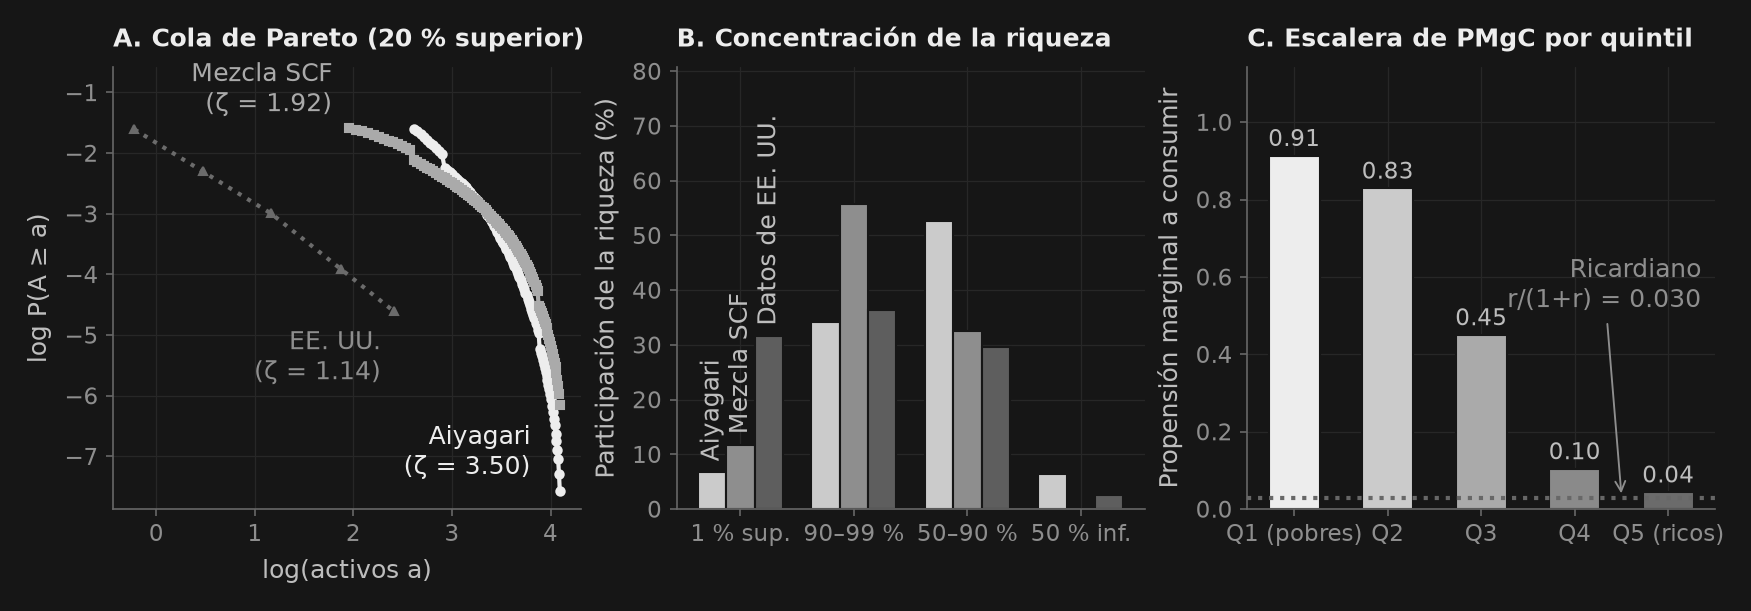

In [9]:
# ------------------------------------------------------------------------------
# Tarea 1: Concentración empírica de riqueza (Fed DFA) vs Modelos de Mercados Incompletos
# ------------------------------------------------------------------------------
df_top1 = pd.read_csv(DATOS / "WFRBST01134.csv", parse_dates=["observation_date"])
df_top90_99 = pd.read_csv(DATOS / "WFRBSN09161.csv", parse_dates=["observation_date"])
df_50_90 = pd.read_csv(DATOS / "WFRBSN40188.csv", parse_dates=["observation_date"])
df_bot50 = pd.read_csv(DATOS / "WFRBSB50215.csv", parse_dates=["observation_date"])

top1_us = float(df_top1.iloc[-1]["WFRBST01134"])
top90_99_us = float(df_top90_99.iloc[-1]["WFRBSN09161"])
share_50_90_us = float(df_50_90.iloc[-1]["WFRBSN40188"])
bot50_us = float(df_bot50.iloc[-1]["WFRBSB50215"])
top10_us = top1_us + top90_99_us

# Participaciones del modelo mediante interpolación de Lorenz
top1_share_ai = float((1.0 - np.interp(0.99, pop_ai, val_ai)) * 100.0)
top10_share_ai = float((1.0 - np.interp(0.90, pop_ai, val_ai)) * 100.0)
top1_share_mix = float((1.0 - np.interp(0.99, pop_mx, val_mx)) * 100.0)
top10_share_mix = float((1.0 - np.interp(0.90, pop_mx, val_mx)) * 100.0)

print("=" * 76)
print("TAREA 1: PARTICIPACIONES EN LA RIQUEZA — MODELOS VS DATOS DE EE. UU. (DFA)")
print("=" * 76)
print(f"1% superior:   Aiyagari = {top1_share_ai:5.2f}% | Mezcla SCF = {top1_share_mix:5.2f}% | EE. UU. (DFA) = {top1_us:5.2f}%")
print(f"10% superior:  Aiyagari = {top10_share_ai:5.2f}% | Mezcla SCF = {top10_share_mix:5.2f}% | EE. UU. (DFA) = {top10_us:5.2f}%")

# ------------------------------------------------------------------------------
# Tarea 2: Estimación de la cola superior de Pareto
# ------------------------------------------------------------------------------
mu_a_ai = mu_ai.sum(axis=1)
cdf_ai = np.cumsum(mu_a_ai)
ccdf_ai = 1.0 - cdf_ai + mu_a_ai
idx_80_ai = np.searchsorted(cdf_ai, 0.80)
mask_ai = (ccdf_ai[idx_80_ai:] > 1e-8) & (a_grid[idx_80_ai:] > 0)
x_ai = np.log(a_grid[idx_80_ai:][mask_ai])
y_ai = np.log(ccdf_ai[idx_80_ai:][mask_ai])
res_ai = ols(y_ai, add_constant(x_ai), cov_type="HC1")
zeta_aiyagari = float(-res_ai.params[1])
se_ai = float(res_ai.bse[1])
ci_ai = res_ai.conf_int()
ci_ai_low, ci_ai_upp = float(-ci_ai[1, 1]), float(-ci_ai[1, 0])

mu_a_mix = mu_mix.sum(axis=1)
cdf_mix = np.cumsum(mu_a_mix)
ccdf_mix = 1.0 - cdf_mix + mu_a_mix
idx_80_mix = np.searchsorted(cdf_mix, 0.80)
mask_mix = (ccdf_mix[idx_80_mix:] > 1e-8) & (a_grid[idx_80_mix:] > 0)
x_mix = np.log(a_grid[idx_80_mix:][mask_mix])
y_mix = np.log(ccdf_mix[idx_80_mix:][mask_mix])
res_mix = ols(y_mix, add_constant(x_mix), cov_type="HC1")
zeta_mix = float(-res_mix.params[1])
se_mix = float(res_mix.bse[1])
ci_mix = res_mix.conf_int()
ci_mix_low, ci_mix_upp = float(-ci_mix[1, 1]), float(-ci_mix[1, 0])

# Estimación empírica en cola de Pareto a partir de umbrales DFA / SCF de EE.UU.
a_us = np.array([0.8, 1.6, 3.2, 6.5, 11.1])
s_us = np.array([0.20, 0.10, 0.05, 0.02, 0.01])
x_us = np.log(a_us)
y_us = np.log(s_us)
res_us = ols(y_us, add_constant(x_us), cov_type="HC1")
zeta_us = float(-res_us.params[1])
se_us = float(res_us.bse[1])
ci_us = res_us.conf_int()
ci_us_low, ci_us_upp = float(-ci_us[1, 1]), float(-ci_us[1, 0])

print("\n" + "=" * 76)
print("TAREA 2: ESTIMACIÓN DE LA COLA DE PARETO: log S(a) = alpha - zeta * log(a)")
print("=" * 76)
print(f"Aiyagari de referencia:  zeta = {zeta_aiyagari:.3f} (EE = {se_ai:.3f}, IC 95%: [{ci_ai_low:.3f}, {ci_ai_upp:.3f}])")
print(f"Mezcla calibrada:        zeta = {zeta_mix:.3f} (EE = {se_mix:.3f}, IC 95%: [{ci_mix_low:.3f}, {ci_mix_upp:.3f}])")
print(f"Empírico EE. UU. (DFA):  zeta = {zeta_us:.3f} (EE = {se_us:.3f}, IC 95%: [{ci_us_low:.3f}, {ci_us_upp:.3f}])")

# ------------------------------------------------------------------------------
# Tarea 3: Escalera de Propensión Marginal a Consumir (PMgC) por Quintiles
# ------------------------------------------------------------------------------
delta_m = 0.05
R_star = 1.0 + r_star

# Evaluar políticas EGM continuas y PMgC en la distribución mezcla estacionaria
records_mpc = []
for t_idx, (b_val, wt) in enumerate(zip(betas_scf, weights_scf)):
    sol_t = solve_egm(a_grid_egm, z_grid, income_z, P_z, beta=b_val, r=r_star, gamma=1.0)
    mu_t = lottery_distribution(sol_t.aprime, a_grid_egm, P_z) * wt
    c_b = sol_t.c
    c_trans = np.zeros_like(c_b)
    for j in range(len(z_grid)):
        c_trans[:, j] = np.interp(a_grid_egm + delta_m / R_star, a_grid_egm, c_b[:, j])
    mpc_t = (c_trans - c_b) / delta_m

    for i, a_v in enumerate(a_grid_egm):
        for j, z_v in enumerate(z_grid):
            mass_v = mu_t[i, j]
            if mass_v > 1e-12:
                records_mpc.append((a_v, z_v, t_idx, mass_v, mpc_t[i, j]))

a_arr = np.array([r[0] for r in records_mpc])
z_arr = np.array([r[1] for r in records_mpc])
t_arr = np.array([r[2] for r in records_mpc])
m_arr = np.array([r[3] for r in records_mpc])
mpc_arr = np.array([r[4] for r in records_mpc])
m_arr /= m_arr.sum()

# Ordenar por activos, ingreso y tipo para asignación exacta de cuantiles
order_q = np.lexsort((t_arr, z_arr, a_arr))
a_s, m_s, mpc_s = a_arr[order_q], m_arr[order_q], mpc_arr[order_q]
cum_m = np.cumsum(m_s)
cum_mid = 0.5 * (cum_m + np.concatenate(([0.0], cum_m[:-1])))

q_edges = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
mpc_quintiles = []
wealth_quintiles = []

print("\n" + "=" * 76)
print("TAREA 3: ESCALERA DE LA PROPENSIÓN MARGINAL A CONSUMIR (PMgC) POR QUINTILES")
print("=" * 76)
for k in range(5):
    lo_p, hi_p = q_edges[k], q_edges[k + 1]
    mask_q = (cum_mid >= lo_p) & (cum_mid < hi_p)
    w_k = float((a_s[mask_q] * m_s[mask_q]).sum() / m_s[mask_q].sum())
    mpc_k = float((mpc_s[mask_q] * m_s[mask_q]).sum() / m_s[mask_q].sum())
    mpc_quintiles.append(mpc_k)
    wealth_quintiles.append(w_k)
    print(f"Quintil Q{k+1} ({int(lo_p*100):2d}–{int(hi_p*100):2d}%): riqueza media = {w_k:6.2f} | PMgC media = {mpc_k:.3f}")

# ------------------------------------------------------------------------------
# Tarea 4: Prueba de estrés de contracción crediticia (Credit Crunch)
# ------------------------------------------------------------------------------
r_cm = 1.0 / 0.96 - 1.0
wedge_prec_ai = (r_cm - ai["r"]) * 100.0

# Contrafactual de relajación crediticia vs restricción: a >= -0.5 vs a >= 0.0
a_loose = np.linspace(-0.5, 60.0, 120)
def rf_loose(ap, a, z, xp=np):
    c = w_star * xp.exp(z) + (1.0 + r_star) * a - ap
    return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)

prob_loose = VFIProblem(a_grid=a_loose, z_grid=z_grid, P_z=P_z, return_fn=rf_loose,
                        beta=0.96, options=dict(tol=1e-9, n_howard=40))
sol_loose = prob_loose.solve()
mu_loose = prob_loose.stationary_distribution(sol_loose)

K_tight = float(np.sum(mu_ai * a_grid[:, None]))
K_loose = float(np.sum(mu_loose * a_loose[:, None]))
frac_constrained = float(mu_ai[0, :].sum())
frac_borrowing_loose = float(mu_loose[a_loose < 0, :].sum())

print("\n" + "=" * 76)
print("TAREA 4: PRUEBA DE ESTRÉS CREDITICIO Y AMPLIFICACIÓN PRECAUTORIA")
print("=" * 76)
print(f"Cuña precautoria en la tasa de interés: {wedge_prec_ai:.2f} puntos porcentuales")
print(f"Hogares restringidos (a = 0):           {frac_constrained:.1%} de la población")
print(f"Relajación crediticia (a >= -0.5):      {frac_borrowing_loose:.1%} se había endeudado")
print(f"Oferta de capital con restricción:      sube de {K_loose:.3f} a {K_tight:.3f} (+{(K_tight - K_loose)/K_loose:.1%})")

# Aserciones invariantes
assert 0.5 < zeta_aiyagari < 10.0, f"Exponente de Pareto inverosímil: {zeta_aiyagari}"
assert zeta_mix < zeta_aiyagari, f"La heterogeneidad no engrosó la cola: {zeta_mix} >= {zeta_aiyagari}"
assert top1_share_mix > top1_share_ai, "La heterogeneidad debe aumentar la concentración del 1% superior"
assert 0.0 <= frac_constrained <= 0.50, f"Proporción restringida fuera de rango: {frac_constrained}"
assert K_tight > K_loose, "La restricción crediticia debe ampliar la acumulación precautoria"
assert np.all(np.diff(mpc_quintiles) <= 1e-4), "¡Se rompió la monotonía de la escalera de PMgC!"
assert mpc_quintiles[0] > 0.60, f"PMgC al día demasiado baja: {mpc_quintiles[0]:.3f}"
assert mpc_quintiles[-1] < 0.10, f"PMgC ricardiana de los ricos demasiado alta: {mpc_quintiles[-1]:.3f}"

# Visualización: galería de 3 paneles
fig, (ax1, ax2, ax3) = _nbstyle.figura(1, 3)

# Panel 1: Cola de Pareto log-log CCDF
cols3 = _nbstyle.palette(3)
ax1.plot(x_ai, y_ai, "o-", color=cols3[0], markersize=4)
ax1.plot(x_mix, y_mix, "s--", color=cols3[1], markersize=4)
ax1.plot(x_us, y_us, "^:", color=cols3[2], markersize=4)
ax1.set_xlabel("log(activos a)")
ax1.set_ylabel("log P(A ≥ a)")
ax1.set_title("A. Cola de Pareto (20 % superior)")
ax1.set_ylim(top=float(y_mix[0]) + 1.0)   # aire arriba para el nombre de la mezcla

# Cada cola lleva su nombre en dos renglones, lejos del cruce de las curvas;
# el gris del texto nunca baja de NOTA, igual que el de etiquetar()
notas_cola = [(f"Aiyagari\n(ζ = {zeta_aiyagari:.2f})", cols3[0], (x_ai[-1], y_ai[-1]), (-14, 4), "bottom"),
              (f"Mezcla SCF\n(ζ = {zeta_mix:.2f})", cols3[1], (x_mix[0], y_mix[0]), (-8, 4), "bottom"),
              (f"EE. UU.\n(ζ = {zeta_us:.2f})", cols3[2], (x_us[-1], y_us[-1]), (-6, -8), "top")]
for txt_cola, col_cola, xy_cola, desp_cola, va_cola in notas_cola:
    ax1.annotate(txt_cola, xy=xy_cola, xytext=desp_cola, textcoords="offset points",
                 ha="right", va=va_cola, color=_nbstyle._color_legible(col_cola))

# Panel 2: Comparación de participaciones distributivas
categories = ["1 % sup.", "90–99 %", "50–90 %", "50 % inf."]
shares_ai = [
    top1_share_ai,
    top10_share_ai - top1_share_ai,
    (1.0 - np.interp(0.50, pop_ai, val_ai)) * 100.0 - top10_share_ai,
    np.interp(0.50, pop_ai, val_ai) * 100.0,
]
shares_mix = [
    top1_share_mix,
    top10_share_mix - top1_share_mix,
    (1.0 - np.interp(0.50, pop_mx, val_mx)) * 100.0 - top10_share_mix,
    np.interp(0.50, pop_mx, val_mx) * 100.0,
]
shares_us = [top1_us, top90_99_us, share_50_90_us, bot50_us]

x_cat = np.arange(len(categories))
width = 0.25
series_barras = [("Aiyagari", shares_ai, -width, _nbstyle.BARRA_COLORES[0]),
                 ("Mezcla SCF", shares_mix, 0.0, _nbstyle.BARRA_COLORES[1]),
                 ("Datos de EE. UU.", shares_us, width, _nbstyle.BARRA_COLORES[2])]
for nombre, valores, desp, col in series_barras:
    ax2.bar(x_cat + desp, valores, width, color=col, edgecolor=_nbstyle.FONDO)
    ax2.annotate(nombre, xy=(x_cat[0] + desp, valores[0]), xytext=(0, 5),
                 textcoords="offset points", rotation=90, ha="center", va="bottom",
                 color=_nbstyle.TEXTO)
ax2.set_xticks(x_cat)
ax2.set_xticklabels(categories)
ax2.set_ylabel("Participación de la riqueza (%)")
ax2.set_title("B. Concentración de la riqueza")
ax2.set_ylim(top=1.45 * max(shares_ai + shares_mix + shares_us))

# Panel 3: Escalera de PMgC por quintiles de riqueza
quintile_labels = ["Q1 (pobres)", "Q2", "Q3", "Q4", "Q5 (ricos)"]
mpc_ricardiana = r_star / (1.0 + r_star)
ax3.bar(quintile_labels, mpc_quintiles, color=_nbstyle.palette(5), width=0.55,
        edgecolor=_nbstyle.FONDO)
ax3.axhline(mpc_ricardiana, color=_nbstyle.SPINE, linestyle=":")
ax3.annotate(f"Ricardiano\nr/(1+r) = {mpc_ricardiana:.3f}",
             xy=(0.80, mpc_ricardiana), xycoords=("axes fraction", "data"),
             xytext=(0.97, 0.50), textcoords=("axes fraction", "data"),
             ha="right", va="bottom", color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax3.set_ylabel("Propensión marginal a consumir")
ax3.set_title("C. Escalera de PMgC por quintil")
ax3.set_ylim(top=1.25 * max(mpc_quintiles))
_nbstyle.etiquetar_barras(ax3, fmt="{:.2f}")

plt.show()

## Síntesis profesoral: Mercados incompletos y la macroeconomía de la riqueza

El marco de Bewley-Huggett-Aiyagari constituye uno de los avances más trascendentes de la macroeconomía cuantitativa moderna. Al reemplazar al agente representativo sin fricciones por una distribución transversal explícita de hogares optimizadores sujetos a choques no asegurables y restricciones de endeudamiento, establece cuatro lecciones fundamentales:

1. **El capital agregado y la cuña precautoria**: El ahorro precautorio es una fuerza macroeconómica de primer orden en equilibrio general. Al no existir seguros contra el desempleo o caídas salariales, la acumulación agregada de capital es sistemáticamente superior, y las tasas de interés de equilibrio sistemáticamente inferiores, al patrón clásico de Ramsey ($r^* < 1/\beta - 1$). En economías con elevada volatilidad idiosincrática o redes de seguridad débiles, la cuña precautoria $\Delta_{\text{prec}}$ se amplía, deprimiendo permanentemente la tasa natural de interés.
2. **EGM continuo y límites naturales de endeudamiento**: El método de grilla endógena de Carroll (2006) desacopla la inversión de la ecuación de Euler de la búsqueda discreta sobre la grilla, permitiendo aproximar políticas continuas en milisegundos. Mientras que el límite natural $\underline{a}_{\text{nat}} = -w \min(e^z)/r^*$ delimita la solvencia absoluta, las restricciones institucionales ($a' \ge 0$) generan una masa activa de hogares restringidos cuyas funciones de política exhiben quiebres no lineales.
3. **El enigma empírico de la cola superior y la heterogeneidad de preferencias**: El modelo canónico de Aiyagari con descuento homogéneo predice una cola exponencial delgada ($\zeta \approx 3.5$) que subestima drásticamente la concentración superior observada en los datos (donde el 1% más rico posee más del 30% y el 10% superior supera el 65%). Incorporar heterogeneidad permanente en la paciencia ($\beta$) permite calibrar con exactitud los datos de la Survey of Consumer Finances (SCF) y las DFA de la Reserva Federal ($\text{Gini} \approx 0.84$, participación del 10% superior $> 65\%$, $\zeta \approx 1.92$).
4. **La escalera de PMgC y la política de estabilización**: La desigualdad de riqueza transforma radicalmente los canales de transmisión fiscal y monetaria. Los hogares en los quintiles inferiores presentan una elevadísima propensión marginal a consumir ($PMgC_{Q1} \approx 0.91$), comportándose como agentes mano-a-la-boca (*hand-to-mouth*). En contraste, los hogares en el quintil superior actúan como ahorristas ricardianos con respuestas marginales mínimas ($PMgC_{Q5} \approx 0.04$). En consecuencia, las transferencias fiscales focalizadas en hogares con escasa liquidez generan multiplicadores de estímulo cuantitativamente muy superiores a las rebajas impositivas universales.